In [33]:
import torch
import torch.nn as nn
import torch.nn.functional as F

from torch.utils.data import DataLoader
from torchvision import datasets, transforms

import matplotlib.pyplot as plt

torch.manual_seed(42)

In [34]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("当前设备:", device)

当前设备: cuda


In [35]:
transform = transforms.ToTensor()

train_dataset = datasets.MNIST(
    root="./data",
    train=True,
    transform=transform,
    download=True
)

test_dataset = datasets.MNIST(
    root="./data",
    train=False,
    transform=transform,
    download=True
)

print("训练集数量:", len(train_dataset))
print("测试集数量:", len(test_dataset))

训练集数量: 60000
测试集数量: 10000


In [36]:
image, label = train_dataset[0]

print("image shape:", image.shape)
print("label:", label)

image shape: torch.Size([1, 28, 28])
label: 5


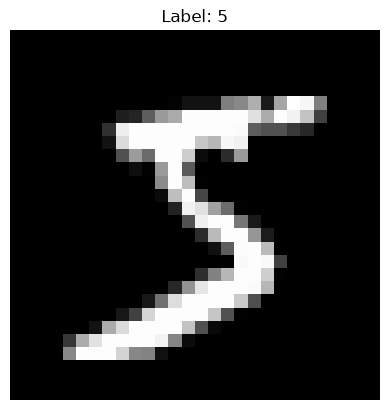

In [37]:
plt.imshow(image.squeeze(), cmap="gray")
plt.title(f"Label: {label}")
plt.axis("off")
plt.show()

In [38]:
batch_size = 64

train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False
)

In [39]:
images, labels = next(iter(train_loader))

print("images shape:", images.shape)
print("labels shape:", labels.shape)

images shape: torch.Size([64, 1, 28, 28])
labels shape: torch.Size([64])


In [40]:
class CNNClassifier(nn.Module):
    def __init__(self):
        super().__init__()
        
        self.conv1 = nn.Conv2d(
            in_channels=1,
            out_channels=8,
            kernel_size=3,
            padding=1
        )
        
        self.pool = nn.MaxPool2d(
            kernel_size=2,
            stride=2
        )
        
        self.conv2 = nn.Conv2d(
            in_channels=8,
            out_channels=16,
            kernel_size=3,
            padding=1
        )
        
        self.fc1 = nn.Linear(16 * 7 * 7, 64)
        self.fc2 = nn.Linear(64, 10)
        
    def forward(self, x):
        # 输入: [batch, 1, 28, 28]
        
        x = self.conv1(x)
        x = F.relu(x)
        x = self.pool(x)
        # [batch, 8, 14, 14]
        
        x = self.conv2(x)
        x = F.relu(x)
        x = self.pool(x)
        # [batch, 16, 7, 7]
        
        x = x.reshape(x.size(0), -1)
        # [batch, 16 * 7 * 7]
        
        x = self.fc1(x)
        x = F.relu(x)
        
        x = self.fc2(x)
        # [batch, 10]
        
        return x

In [41]:
model = CNNClassifier().to(device)

print(model)

CNNClassifier(
  (conv1): Conv2d(1, 8, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv2): Conv2d(8, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (fc1): Linear(in_features=784, out_features=64, bias=True)
  (fc2): Linear(in_features=64, out_features=10, bias=True)
)


In [42]:
loss_fn = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

In [43]:
epochs = 10

train_losses = []

for epoch in range(epochs):
    model.train()
    
    total_loss = 0
    
    for images, labels in train_loader:
        images = images.to(device)
        labels = labels.to(device)
        
        # 1. 前向传播
        outputs = model(images)
        
        # 2. 计算损失
        loss = loss_fn(outputs, labels)
        
        # 3. 梯度清零
        optimizer.zero_grad()
        
        # 4. 反向传播
        loss.backward()
        
        # 5. 参数更新
        optimizer.step()
        
        total_loss += loss.item()
    
    avg_loss = total_loss / len(train_loader)
    train_losses.append(avg_loss)
    
    print(f"Epoch [{epoch+1}/{epochs}], Loss: {avg_loss:.4f}")

Epoch [1/10], Loss: 0.3035
Epoch [2/10], Loss: 0.0858
Epoch [3/10], Loss: 0.0607
Epoch [4/10], Loss: 0.0486
Epoch [5/10], Loss: 0.0391
Epoch [6/10], Loss: 0.0332
Epoch [7/10], Loss: 0.0281
Epoch [8/10], Loss: 0.0243
Epoch [9/10], Loss: 0.0204
Epoch [10/10], Loss: 0.0180


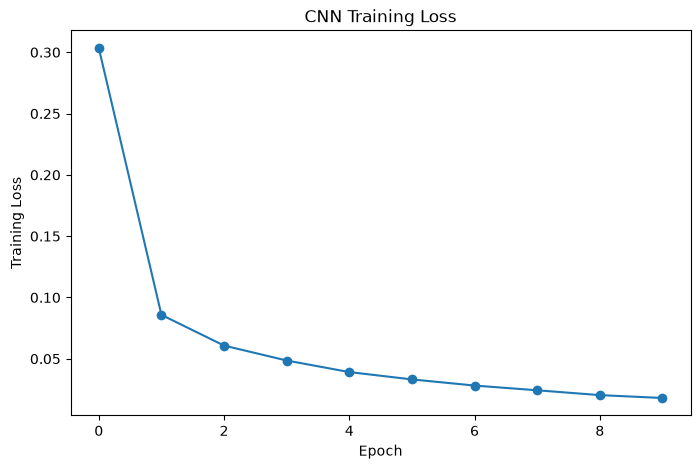

In [44]:
plt.figure(figsize=(8, 5))
plt.plot(train_losses, marker="o")
plt.xlabel("Epoch")
plt.ylabel("Training Loss")
plt.title("CNN Training Loss")
plt.show()

In [45]:
model.eval()

correct = 0
total = 0

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)
        
        outputs = model(images)
        
        _, predicted = torch.max(outputs, dim=1)
        
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

accuracy = correct / total

print(f"测试集准确率: {accuracy:.4f}")

测试集准确率: 0.9898


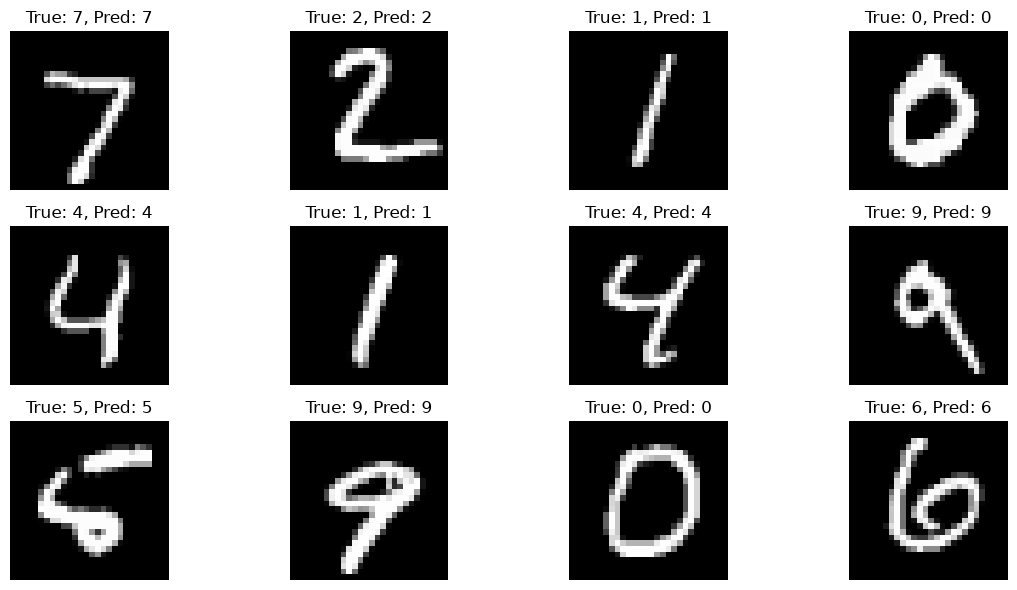

In [46]:
model.eval()

images, labels = next(iter(test_loader))

images = images.to(device)
labels = labels.to(device)

with torch.no_grad():
    outputs = model(images)
    _, predicted = torch.max(outputs, dim=1)

images = images.cpu()
labels = labels.cpu()
predicted = predicted.cpu()

plt.figure(figsize=(12, 6))

for i in range(12):
    plt.subplot(3, 4, i + 1)
    plt.imshow(images[i].squeeze(), cmap="gray")
    plt.title(f"True: {labels[i].item()}, Pred: {predicted[i].item()}")
    plt.axis("off")

plt.tight_layout()
plt.show()